In [1]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import seaborn as sns


sys.path.insert(0, '../scripts')
from data_utils import get_concatenated_transformed_obs_columns

In [8]:
# working locally?
IS_RUN_LOCALLY = False

# paths
if IS_RUN_LOCALLY:
    H5AD_PATH = "/Users/lorenzo.consoli/Work/data/collab-goettgens/ds_HID01_logicle_100k_UMAP_ann.h5ad"
else:
    H5AD_PATH = "../project_folder/gdrive/ds_HID01_logicle_100k_UMAP_ann.h5ad"

# Tranformations
LOG1P_EXP_COL = [
    "um171_[nm]",
    "um729_[µm]",
    "scf_[ng_ml]",
    "butyzamide_[nm]",
    "o2_[%]",
    "sr1_[nm]",
    "mtg_[µm]",
    "rhflt3l_[ng_ml]",
    "gm-csf_[ng_ml]",
    "days_of_culture",
]
LOG21P_EXP_COL = [
    "ldl_[ng_ml]", 
    "il3_[ng_ml]",
    "retinoic_acid_[µm]",
    "tpo_[ng_ml]",
]

EXPERIMENTAL_COVARIATES = [
    # '740-yp_[µm]', 'mtg_[µm]',
    # 'rhflt3l_[ng_ml]', 
    'gm-csf_[ng_ml]',
    'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]',
    'um729_[µm]', 'scf_[ng_ml]',
    'butyzamide_[nm]', 'retinoic_acid_[µm]',
    'ldl_[ng_ml]', 'il3_[ng_ml]',
    'o2_[%]', 'days_of_culture'
]
PROTOCOL_CONCAT_OBSM_KEY = "condition_concat"

In [9]:
col2transf = {}
for col in EXPERIMENTAL_COVARIATES:
    if col in LOG1P_EXP_COL:
        col2transf[col] = np.log1p
    elif col in LOG21P_EXP_COL:
        col2transf[col] = lambda x: np.log2(x + 1)
    else:
        col2transf[col] = None
print(col2transf)

{'gm-csf_[ng_ml]': <ufunc 'log1p'>, 'tpo_[ng_ml]': <function <lambda> at 0x7ff49444b060>, 'sr1_[nm]': <ufunc 'log1p'>, 'um171_[nm]': <ufunc 'log1p'>, 'um729_[µm]': <ufunc 'log1p'>, 'scf_[ng_ml]': <ufunc 'log1p'>, 'butyzamide_[nm]': <ufunc 'log1p'>, 'retinoic_acid_[µm]': <function <lambda> at 0x7ff49444b1a0>, 'ldl_[ng_ml]': <function <lambda> at 0x7ff49444b600>, 'il3_[ng_ml]': <function <lambda> at 0x7ff493d51760>, 'o2_[%]': <ufunc 'log1p'>, 'days_of_culture': <ufunc 'log1p'>}


In [10]:
adata = sc.read_h5ad(H5AD_PATH)
adata

AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap'
    obsm: 'X_pca', 'X_umap'
    layers: 'positives', 'raw'
    

In [15]:
adata = get_concatenated_transformed_obs_columns(adata, col2transf, obsm_col=PROTOCOL_CONCAT_OBSM_KEY)
adata = get_concatenated_transformed_obs_columns(adata, {k:None for k in col2transf}, obsm_col=f"untransformed_{PROTOCOL_CONCAT_OBSM_KEY}")
adata

AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap'
    obsm: 'X_pca', 'X_umap', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', '

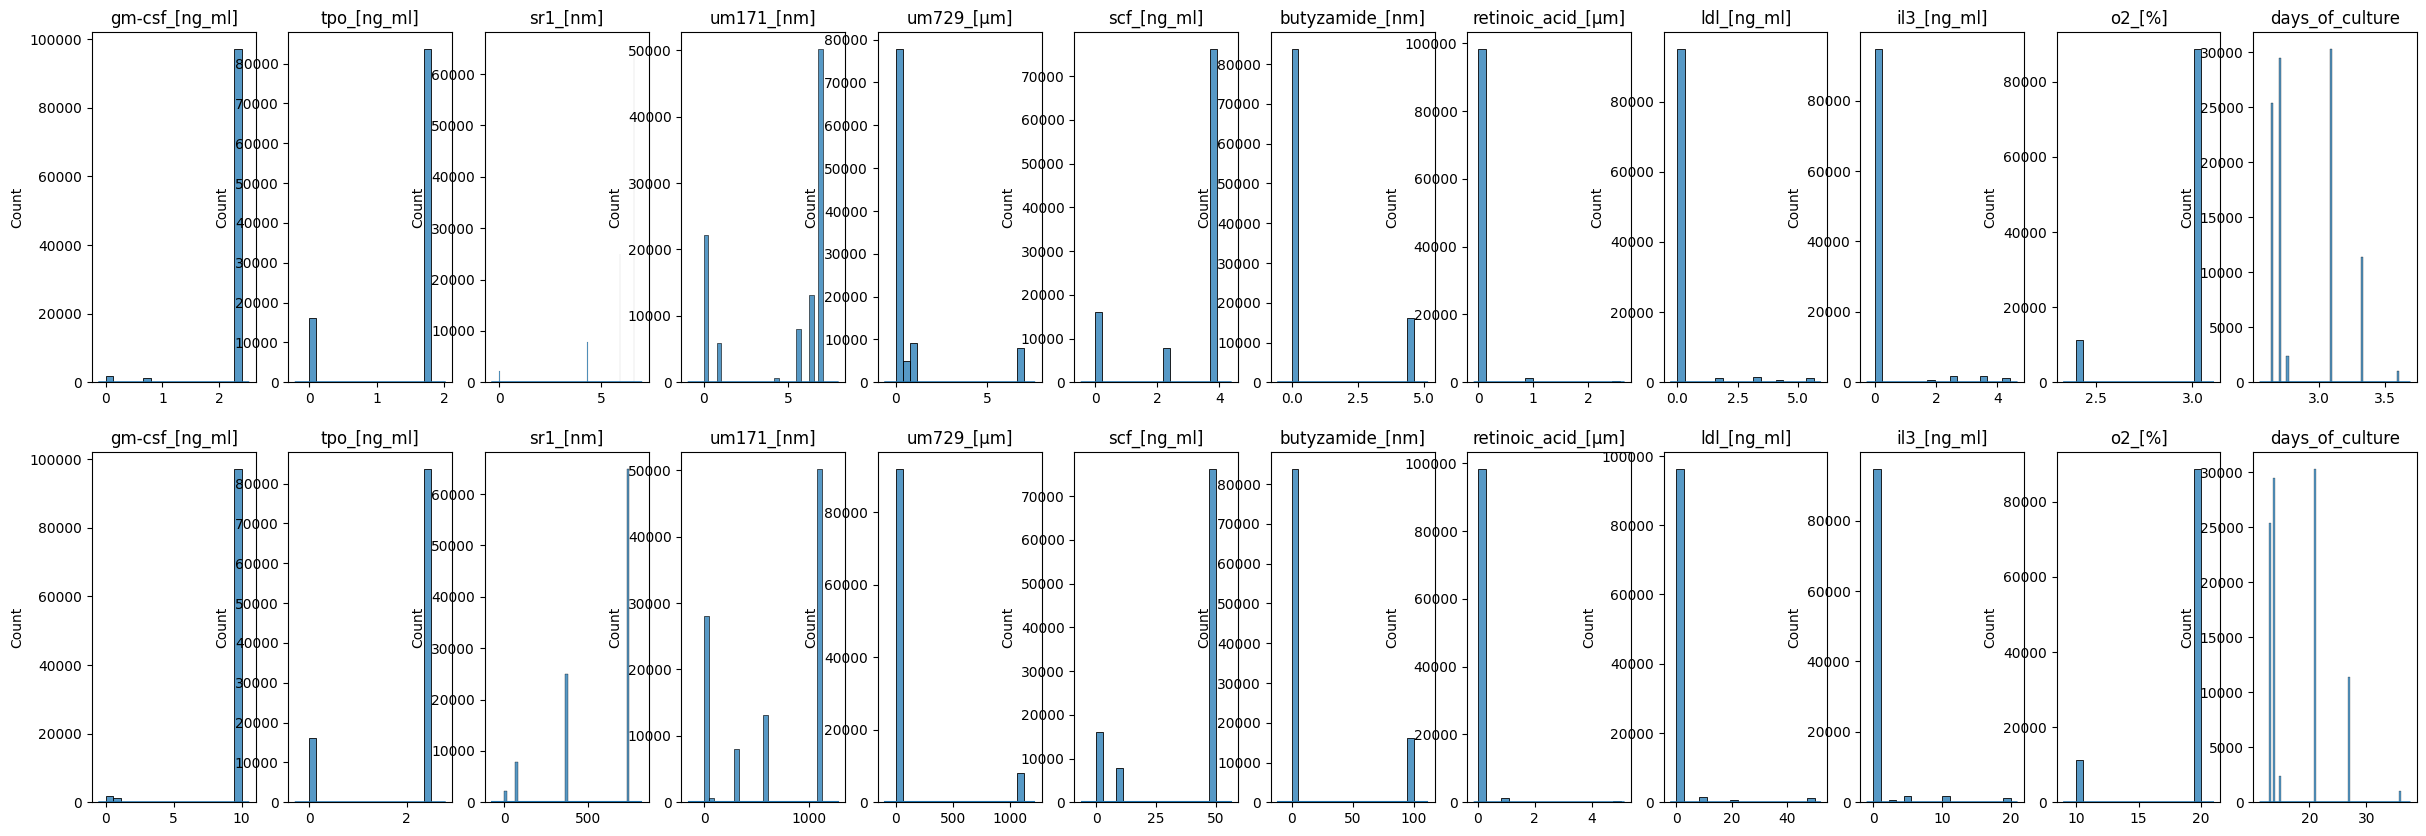

In [17]:
fig, ax = plt.subplots(2, len(EXPERIMENTAL_COVARIATES), figsize=(30, 10))
for idx, col in enumerate(EXPERIMENTAL_COVARIATES):
    ax[0, idx].set_title(col)
    sns.histplot(adata.obsm[PROTOCOL_CONCAT_OBSM_KEY][:, idx], ax=ax[0, idx])
    sns.kdeplot(adata.obsm[PROTOCOL_CONCAT_OBSM_KEY][:, idx], ax=ax[0, idx])

    ax[1, idx].set_title(col)
    sns.histplot(adata.obsm[f"untransformed_{PROTOCOL_CONCAT_OBSM_KEY}"][:, idx], ax=ax[1, idx])
    sns.kdeplot(adata.obsm[f"untransformed_{PROTOCOL_CONCAT_OBSM_KEY}"][:, idx], ax=ax[1, idx])

In [ ]:
# example_preprocessing.py
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, RobustScaler, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
import joblib

# --- 1) list your columns ---
cols = [
    'gm-csf_[ng_ml]',
    'tpo_[ng_ml]',
    'sr1_[nm]',        # ambiguous: could be concentration in nM?
    'um171_[nm]',
    'um729_[µm]',
    'scf_[ng_ml]',
    'butyzamide_[nm]',
    'retinoic_acid_[µm]',
    'ldl_[ng_ml]',
    'il3_[ng_ml]',
    'o2_[%]',
    'days_of_culture'
]

# --- 2) create custom converters for units (adjust per your true units) ---
def convert_units(df):
    df = df.copy()
    # Example assumptions (please verify):
    # - convert nanomolar (nM) to micromolar (uM): nM * 1e-3
    # - convert µm (if it is µM concentration) to µM (identity)
    # - convert percent to fraction
    # Adjust these mappings to your real units.
    for c in ['sr1_[nm]', 'um171_[nm]', 'butyzamide_[nm]']:
        if c in df.columns:
            df[c] = df[c].astype(float) * 1e-3  # nM -> µM
    for c in ['um729_[µm]', 'retinoic_acid_[µm]']:
        if c in df.columns:
            df[c] = df[c].astype(float)  # assume already µM
    if 'o2_[%]' in df.columns:
        df['o2_[%]'] = df['o2_[%]'].astype(float) / 100.0
    return df

convert_transformer = FunctionTransformer(convert_units)

# --- 3) choose feature groups for different transforms ---
log_features = [
    'gm-csf_[ng_ml]', 'tpo_[ng_ml]',
    'scf_[ng_ml]', 'ldl_[ng_ml]', 'il3_[ng_ml]',
    # Note: if you converted nM->µM earlier, include those small molecule concs:
    'sr1_[nm]', 'um171_[nm]', 'butyzamide_[nm]',
    'um729_[µm]', 'retinoic_acid_[µm]'
]
frac_features = ['o2_[%]']
count_features = ['days_of_culture']

# --- 4) transformer pipelines ---
# for skewed positive features: impute -> log1p -> scale
skew_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(lambda x: np.log1p(x.astype(float)), validate=False)),
    ('scaler', StandardScaler())
])

# for O2 (now fraction): impute + scaler
frac_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# for days: impute + maybe log + scaler
days_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(lambda x: np.log1p(x.astype(float)), validate=False)),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('skew', skew_pipeline, [c for c in log_features if c in cols]),
    ('frac', frac_pipeline, [c for c in frac_features if c in cols]),
    ('days', days_pipeline, [c for c in count_features if c in cols]),
], remainder='drop')

# final pipeline
full_pipe = Pipeline([
    ('unit_conv', convert_transformer),
    ('preproc', preprocessor)
])

# Example usage
df_train = adata.obs
X_train_prepared = full_pipe.fit_transform(df_train[cols])
# Save pipeline
# joblib.dump(full_pipe, 'preprocessing_pipeline.joblib')


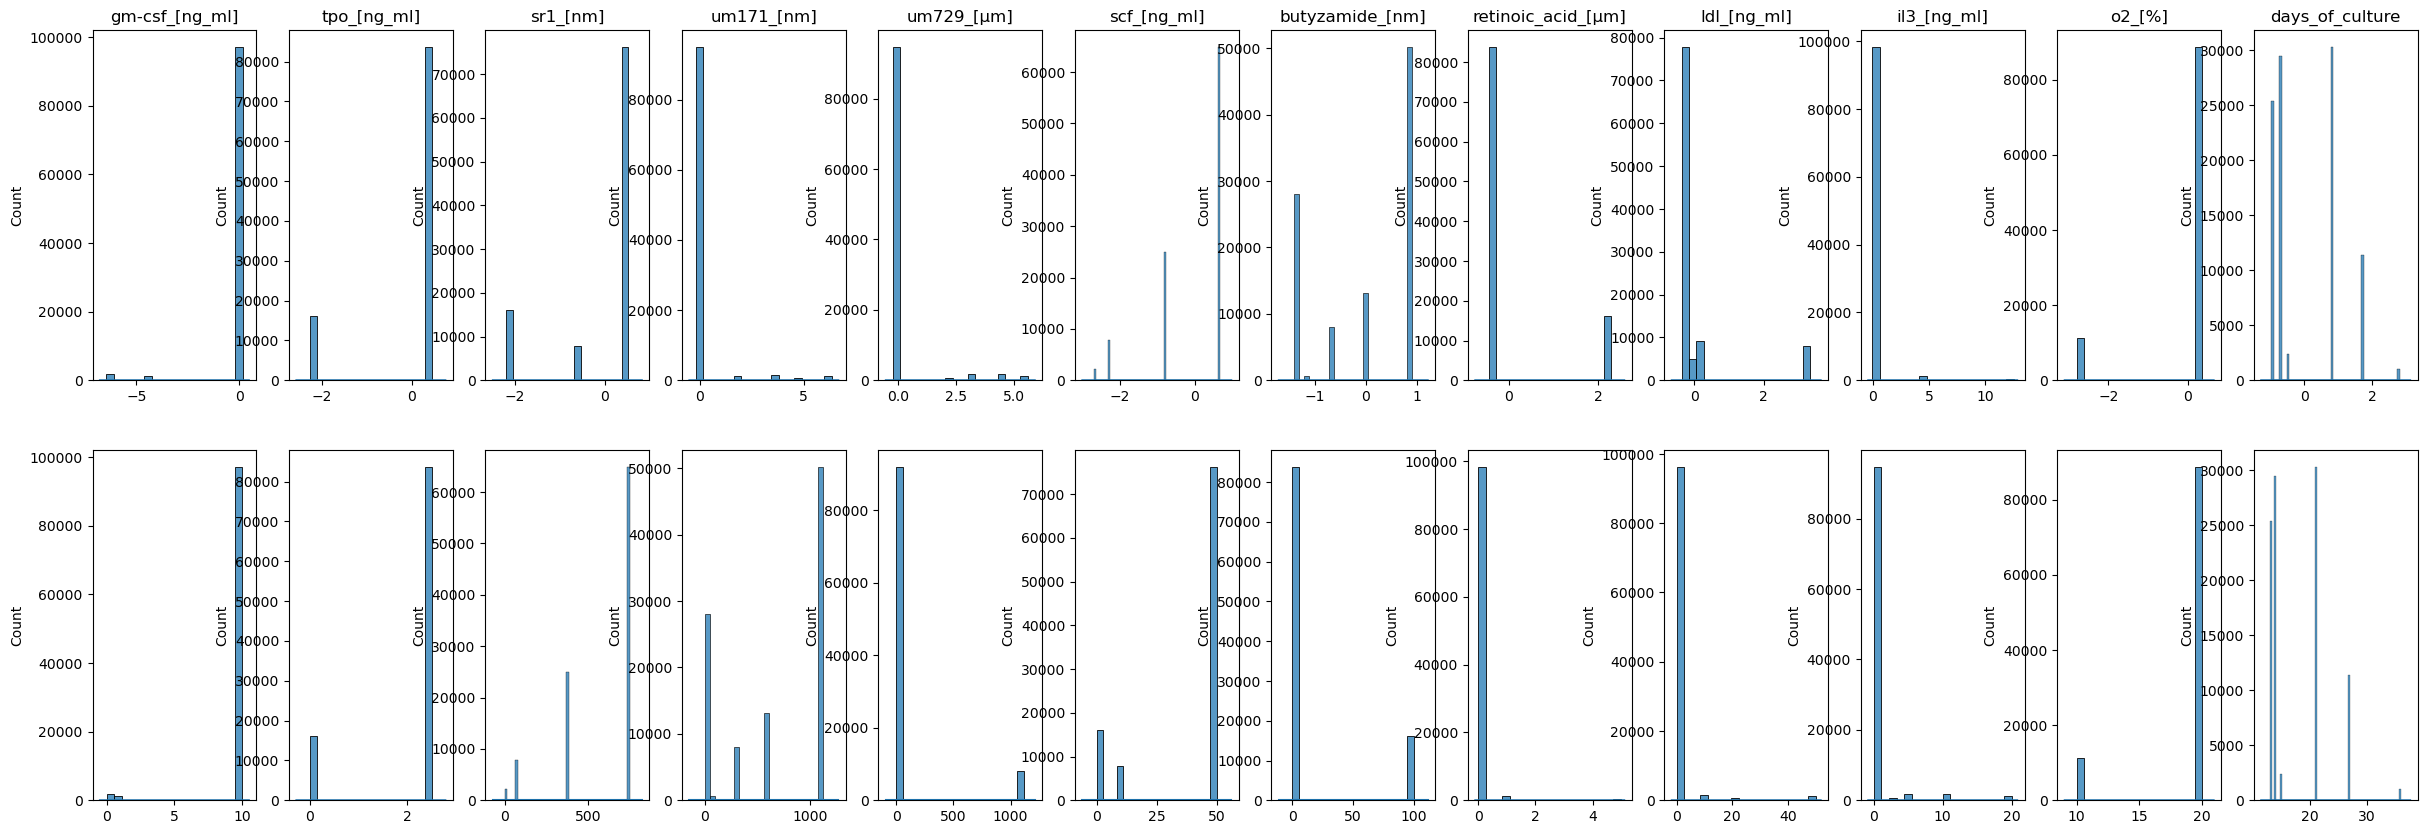

In [ ]:
fig, ax = plt.subplots(2, len(EXPERIMENTAL_COVARIATES), figsize=(30, 10))
for idx, col in enumerate(EXPERIMENTAL_COVARIATES):
    # plt.figure()
    ax[0, idx].set_title(col)
    # ax[1, idx].set_title(col)
    sns.histplot(adata.obsm[f"untransformed_{PROTOCOL_CONCAT_OBSM_KEY}"][:, idx], ax=ax[1, idx])
    sns.kdeplot(adata.obsm[f"untransformed_{PROTOCOL_CONCAT_OBSM_KEY}"][:, idx], ax=ax[1, idx])

    sns.histplot(X_train_prepared[:, idx], ax=ax[0, idx])
    sns.kdeplot(X_train_prepared[:, idx], ax=ax[0, idx])
